In [1]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(stringr)

netflix_data <- read.csv("data/netflix_titles.csv")


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# **Hypothesis 1**: The most common genres vary by the type of content (Movies vs. TV Shows)

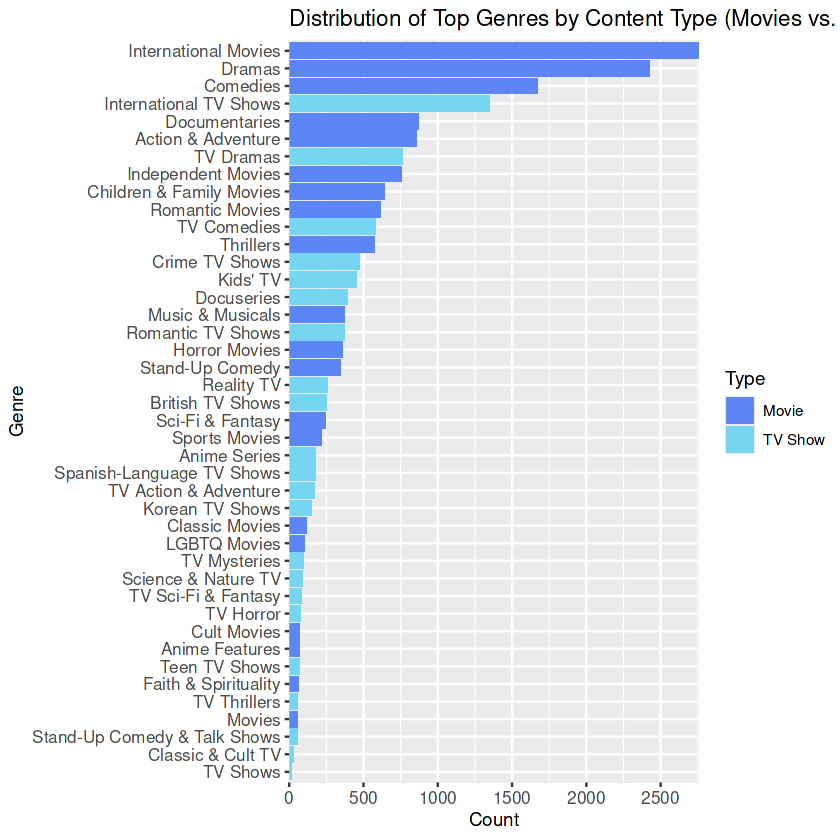

In [2]:
netflix_genres <- netflix_data %>%
  filter(!is.na(listed_in)) %>%
  mutate(genre = strsplit(as.character(listed_in), ", ")) %>%
  unnest(genre) %>%
  group_by(type, genre) %>%
  summarise(count = n(), .groups = 'drop') %>%
  arrange(type, desc(count))

ggplot(data = netflix_genres, aes(y = reorder(genre, count), x = count, fill = type)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Distribution of Top Genres by Content Type (Movies vs. TV Shows)", 
       x = "Count", y = "Genre", fill = "Type") + 
  scale_x_continuous(breaks = seq(0, max(netflix_genres$count), by = 500), expand = c(0, 0)) + 
  scale_fill_manual(values = c("Movie" = "#5c86f4", "TV Show" = "#76d5f1")) + 
  theme(axis.text.y = element_text(size = 10), 
        axis.text.x = element_text(size = 10))

# **Hypothesis 2**: The number of titles added to Netflix has changed over time

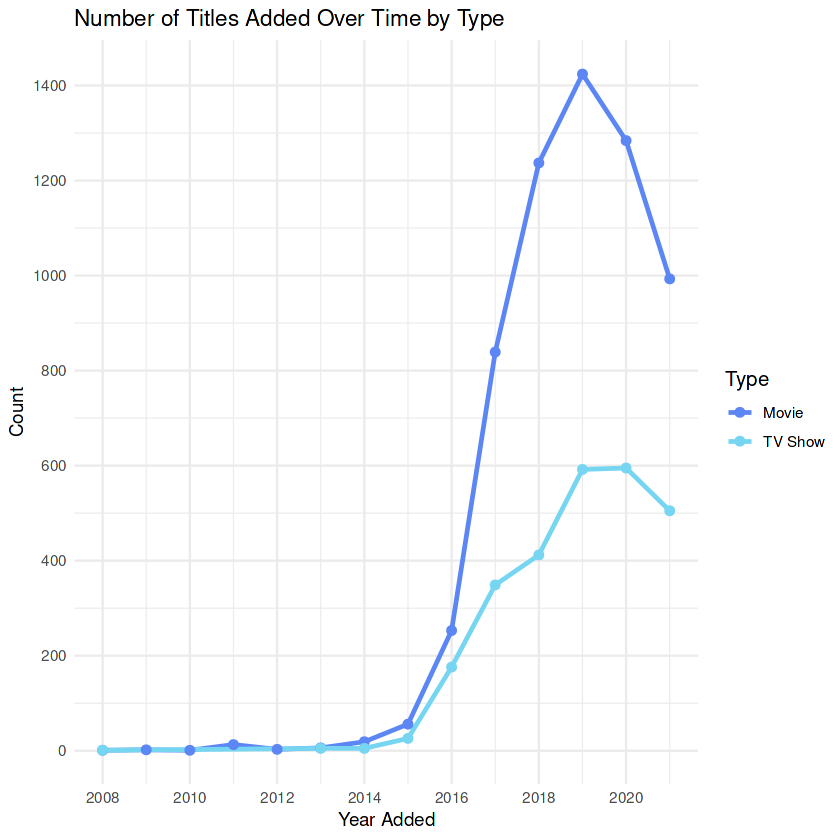

In [3]:
yearly_counts <- netflix_data %>%
  filter(!is.na(date_added)) %>%  
  mutate(year_added = as.numeric(str_extract(date_added, "\\d{4}"))) %>%
  filter(!is.na(year_added) & year_added >= 1900 & year_added <= 2100) %>%  
  group_by(year_added, type) %>%
  summarise(count = n(), .groups = 'drop')  

ggplot(data = yearly_counts, aes(x = year_added, y = count, color = type)) +
  geom_line(linewidth = 1) +  # Replaced `size` with `linewidth`
  geom_point(size = 2) +
  scale_x_continuous(breaks = seq(min(yearly_counts$year_added), max(yearly_counts$year_added), by = 2)) +  
  scale_y_continuous(breaks = seq(0, max(yearly_counts$count), by = 200)) +  
  scale_color_manual(values = c("Movie" = "#5c86f4", "TV Show" = "#76d5f1"), name = "Type") +  
  labs(title = "Number of Titles Added Over Time by Type", x = "Year Added", y = "Count") +
  theme_minimal() +
  theme(legend.title = element_text(size = 12))

# **Hypothesis 3**: The duration of movies differs by rating category

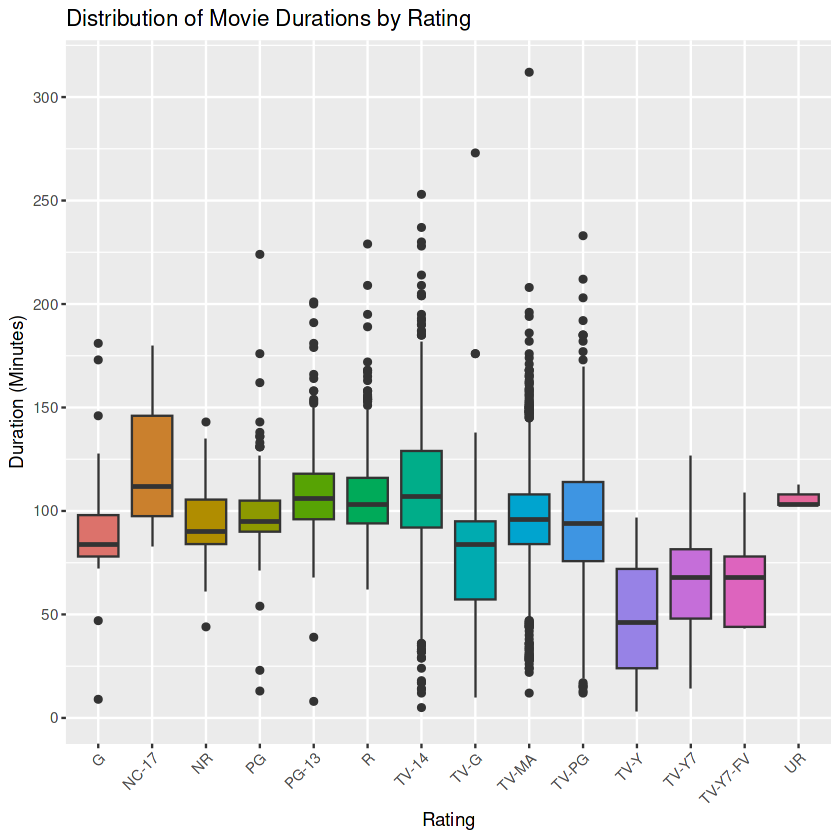

In [4]:
valid_ratings <- c("NC-17", "TV-14", "PG-13", "R", "UR", "PG", "TV-MA", "TV-PG", 
                   "NR", "G", "TV-G", "TV-Y7-FV", "TV-Y7", "TV-Y")

movies_data <- netflix_data %>%
  filter(type == "Movie" & 
           !is.na(duration) & 
           grepl("\\d+", duration) &  
           rating %in% valid_ratings) %>%  
  mutate(duration_min = as.numeric(str_extract(duration, "\\d+"))) %>%
  filter(!is.na(duration_min))  

rating_duration_df <- movies_data %>%
  group_by(rating) %>%
  summarise(Mean_Duration = mean(duration_min, na.rm = TRUE), .groups = 'drop') %>%
  arrange(desc(Mean_Duration))

ggplot(data = movies_data, aes(x = rating, y = duration_min, fill = rating)) +
  geom_boxplot() +
  scale_y_continuous(breaks = seq(0, max(movies_data$duration_min), by = 50)) +  
  scale_fill_manual(values = scales::hue_pal(l = 60, c = 80)(length(valid_ratings)), guide = "none") +  
  labs(title = "Distribution of Movie Durations by Rating", x = "Rating", y = "Duration (Minutes)") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


# **Hypothesis 4**: The top countries producing content have shifted over the years

[1] "Excluded rows due to missing/blank 'country': 831"


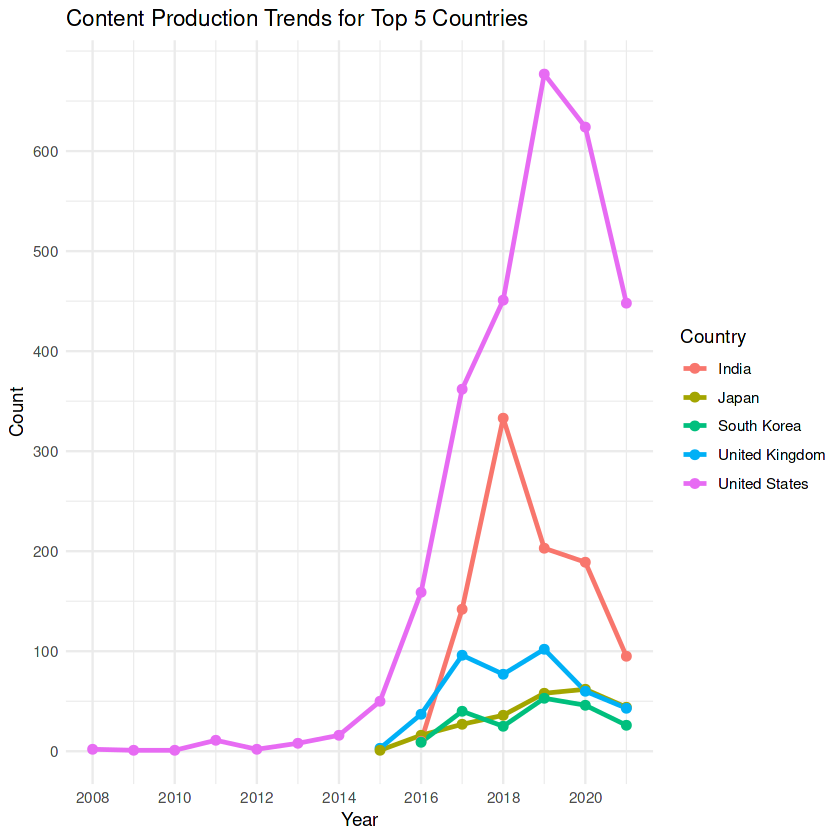

In [5]:
excluded_countries <- netflix_data %>% filter(is.na(country) | country == "")
print(paste("Excluded rows due to missing/blank 'country':", nrow(excluded_countries)))

top_countries <- netflix_data %>%
  filter(!is.na(country) & country != "") %>%
  count(country, sort = TRUE) %>%
  arrange(desc(n), country) %>%
  slice(1:5) %>%
  pull(country)

country_trends <- netflix_data %>%
  mutate(year_added = as.numeric(str_extract(date_added, "\\d{4}"))) %>%
  filter(!is.na(year_added) & year_added >= 1900 & year_added <= 2100 & !is.na(country) & country != "") %>%
  group_by(year_added, country) %>%
  summarise(count = n(), .groups = 'drop') %>%
  arrange(year_added, desc(count))

country_trends_filtered <- country_trends %>%
  filter(country %in% top_countries)

ggplot(data = country_trends_filtered, aes(x = year_added, y = count, color = country)) +
  geom_line(linewidth = 1) +  # Replaced `size` with `linewidth`
  geom_point(size = 2) +  
  scale_x_continuous(breaks = seq(min(country_trends_filtered$year_added), max(country_trends_filtered$year_added), by = 2)) +  
  scale_y_continuous(breaks = seq(0, max(country_trends_filtered$count), by = 100)) +  
  labs(title = "Content Production Trends for Top 5 Countries", x = "Year", y = "Count", color = "Country") +  
  theme_minimal()

# **Hypothesis 5**: TV shows with specific keywords in the description are more popular in certain genres

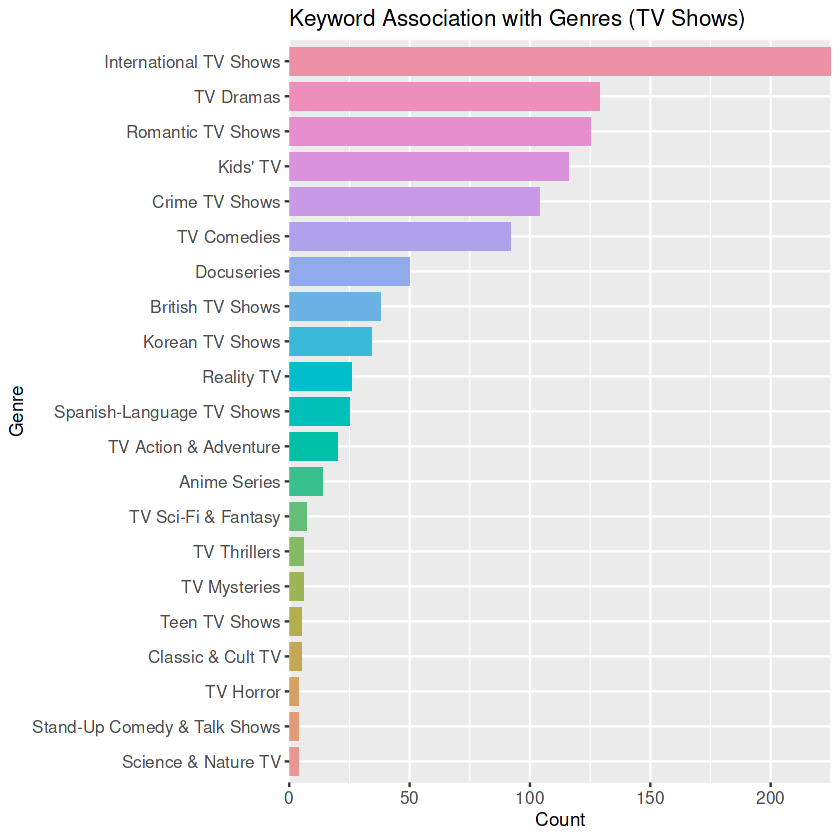

In [6]:
tv_shows_with_keywords <- netflix_data %>%
  filter(type == "TV Show" & 
           !is.na(description) & description != "" & 
           !is.na(listed_in) & listed_in != "") %>%  
  mutate(keyword_flag = str_detect(description, regex("love|crime|adventure", ignore_case = TRUE))) %>%
  filter(keyword_flag == TRUE) %>%
  mutate(genre = lapply(as.character(listed_in), function(x) strsplit(x, ", ")[[1]])) %>%
  unnest(genre) %>%
  filter(genre != "" & !is.na(genre))  

genre_keyword_analysis <- tv_shows_with_keywords %>%
  group_by(genre) %>%
  summarise(count = n(), .groups = 'drop') %>%
  arrange(desc(count))

soft_rainbow_colors <- scales::hue_pal(l = 70, c = 60)(nrow(genre_keyword_analysis))  

ggplot(data = genre_keyword_analysis, aes(x = count, y = reorder(genre, count), fill = reorder(genre, count))) +
  geom_bar(stat = "identity", width = 0.8) +  
  scale_x_continuous(breaks = seq(0, max(genre_keyword_analysis$count), by = 50), expand = c(0, 0)) +  
  scale_fill_manual(values = soft_rainbow_colors, guide = "none") +  
  labs(title = "Keyword Association with Genres (TV Shows)", x = "Count", y = "Genre") +
  theme(axis.text.y = element_text(size = 10), 
        axis.text.x = element_text(size = 10))